### Problem Statement
Load and explore the Iris dataset using pandas, then summarize and visualize its structure and distributions to understand feature relationships and detect outliers.

#### Goal
- Load the dataset and display its shape, column names, and first rows using `.head()`
- Use `.info()` and `.describe()` for summaries
- Visualize feature relationships with scatter plots
- Show distributions with histograms and detect outliers with box plots
- Use `matplotlib` and `seaborn` for plotting

In [ ]:
# Import libraries for data handling and plotting
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

d:\Program Files\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


In [ ]:
# Load the Iris dataset (features + target)
iris = load_iris()

In [ ]:
# Create DataFrame from the dataset and add the target species column
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [ ]:
# Show the shape of the DataFrame (rows, columns)
df.shape

(150, 5)

In [ ]:
# List column names to understand available features
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [ ]:
# Display the first few rows to inspect values and target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# Show concise info: dtypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
# Summary statistics (count, mean, std, min, max, quartiles)
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


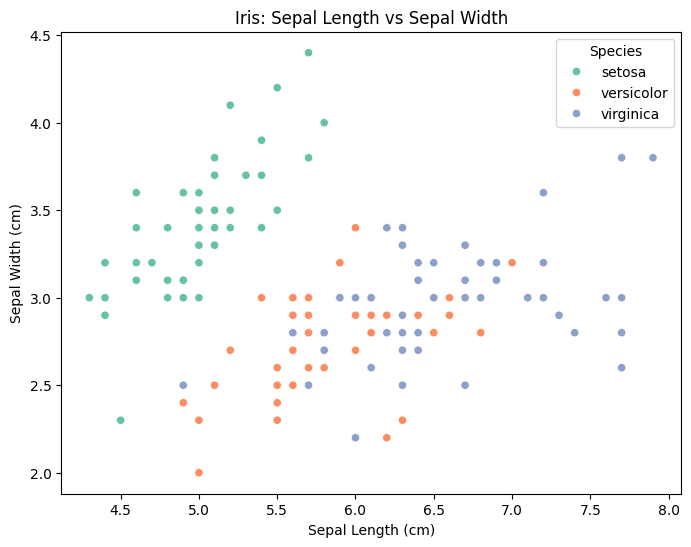

In [ ]:
# Scatter plot: sepal length vs sepal width colored by species
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    hue=df['target'].map(dict(enumerate(iris.target_names))),
    palette='Set2'
 )
plt.title('Iris: Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.show()

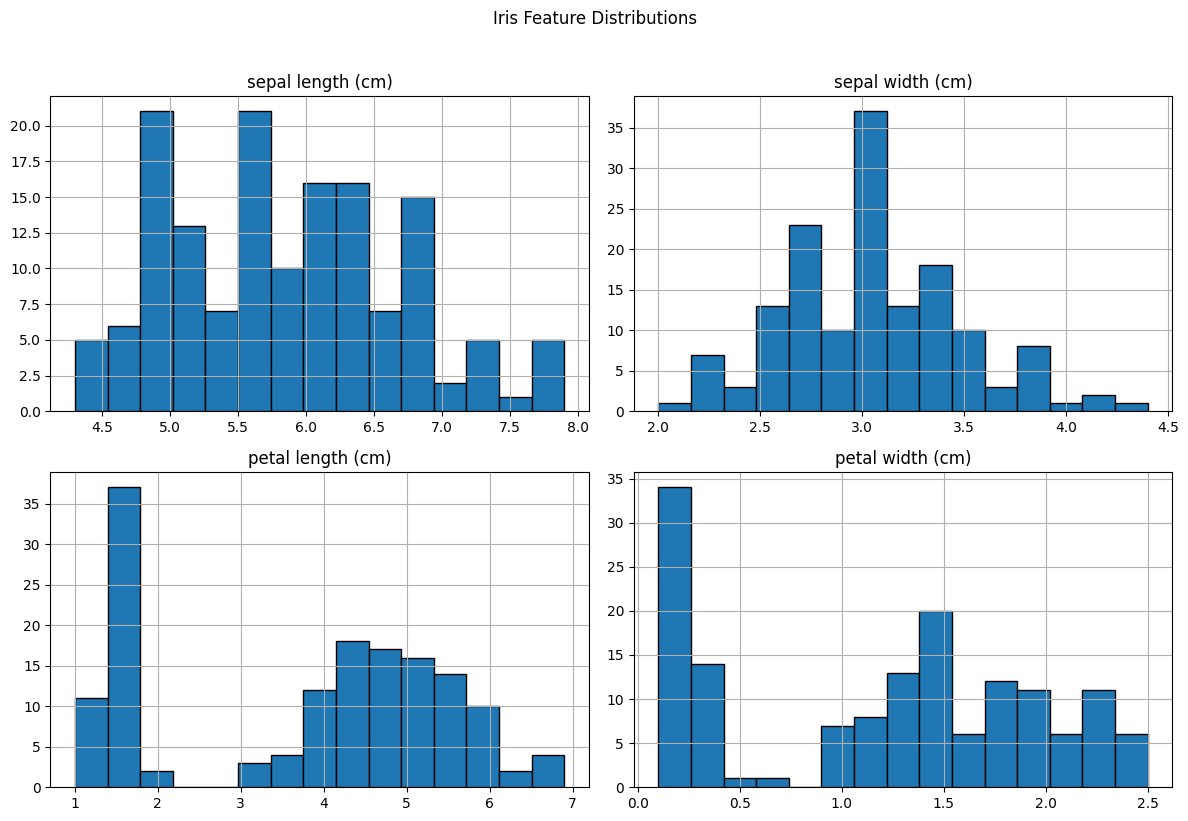

In [ ]:
# Histograms: visualize distribution of each numeric feature
df.drop(columns=['target']).hist(bins=15, figsize=(12, 8), edgecolor='black')
plt.suptitle('Iris Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

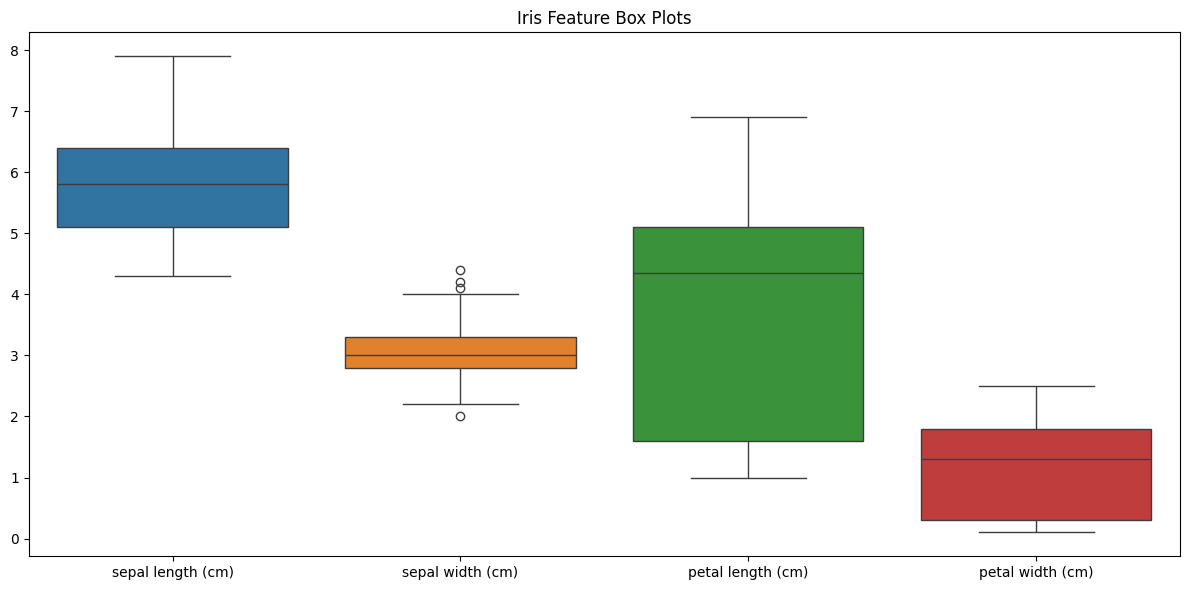

In [ ]:
# Box plots: check for potential outliers per feature
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=['target']))
plt.title('Iris Feature Box Plots')
plt.tight_layout()
plt.show()

**Explanation of Results**
- Scatter plot: sepal length and sepal width show overlap between species; species separation is clearer for petal measurements (not shown here).
- Histograms: most features are approximately normally distributed, with petal length/width showing clearer separation across species.
- Box plots: a few mild outliers are present but no extreme data-quality issues were observed.

**Final Insights**
- Petal length and petal width are the most discriminative features for separating Iris species.
- Sepal measurements overlap more and are less useful alone for classification.
- Data is clean and ready for simple modeling (e.g., k-NN, logistic regression, or decision trees).